# ST5011CEM Big Data Programming Project
# Samriddha Raj Satyal 
# CU ID: 15940432

# Arriva Merseyside Fare-Aware Service Reliability Audit
# Stakeholder: Transport Authority / Local Council Merseytravel / Liverpool City Region

---

### Reducing the unnnecessary warnings as it will look bad during coursework report submission:

In [1]:
import os
import warnings
import logging

# Hiding warnings coming from python
warnings.filterwarnings("ignore")
os.environ["PYTHONWARNINGS"] = "ignore"

# To reduce all logs output
for logger in [
    "py4j",
    "py4j.clientserver",
    "pyspark",
    "matplotlib",
    "urllib3",
    "asyncio",
]:
    logging.getLogger(logger).setLevel(logging.ERROR)


java_opts = (
    "-Dlog4j2.rootLogger=ERROR,console "
    "-Dorg.slf4j.simpleLogger.defaultLogLevel=error"
)

existing = os.environ.get("JAVA_TOOL_OPTIONS", "")
os.environ["JAVA_TOOL_OPTIONS"] = f"{existing} {java_opts}".strip()

os.environ.setdefault(
    "PYSPARK_SUBMIT_ARGS",
    f'--driver-java-options "{java_opts}" '
    "--conf spark.ui.showConsoleProgress=false pyspark-shell",
)


def quiet_spark(spark):
    """Reduce Spark log output after creating the session."""
    try:
        spark.sparkContext.setLogLevel("ERROR")
    except Exception:
        pass
    return spark


print("Logging configured.")

Logging configured.


In [1]:
%matplotlib inline

from __future__ import annotations

import os
import sys
import re
import json
import time
import sqlite3
from pathlib import Path
from typing import Any, Iterable
from xml.etree import ElementTree as ET

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shutil

sns.set_theme(style="whitegrid")

from IPython.display import display, Markdown, Image

from pyspark.sql import SparkSession, DataFrame
from pyspark.sql import functions as F
from pyspark.sql.functions import broadcast
from pyspark.sql.window import Window
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.ml.classification import LogisticRegression, RandomForestClassifier, GBTClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
from pyspark.ml.functions import vector_to_array


In [2]:
#opening project folder
CWD = Path.cwd().resolve()
if (CWD / "datasets").exists():
    PROJECT = CWD
elif (CWD.parent / "datasets").exists():
    PROJECT = CWD.parent
else:
    raise FileNotFoundError("Run from coursework/ — datasets/ not found")

In [3]:
#making the outputs and visuals folder because later it will be used for storing result and renaming folders
(PROJECT / "outputs").mkdir(parents=True, exist_ok=True)
(PROJECT / "visuals").mkdir(parents=True, exist_ok=True)
DATASETS = PROJECT / "datasets"
OUT = PROJECT / "outputs"
VIS = PROJECT / "visuals"
TIMETABLE_DIR = DATASETS / "timetable"
FARES_DIR = DATASETS / "fares"
LOCATION_DIR = DATASETS / "location"
DISRUPTIONS_COMBINED = DATASETS / "disruptions_processed" / "disruptions_combined.csv"
PROCESSED_DIR = OUT / "processed"
DATA_QUALITY_DIR = OUT / "data_quality"
DB_DIR = OUT / "db"
DB_PATH = DB_DIR / "merseyside_reliability_audit.sqlite"
RELIABILITY_DIR = OUT / "reliability"
FEATURES_DIR = OUT / "features"
DB_SCHEMA_DIR = OUT / "database_schema"
ML_DIR = OUT / "machine_learning"
DASHBOARD_EXPORTS_DIR = OUT / "dashboard_exports"
DATA_EXPLORATION_DIR = VIS / "data_exploration"

#defining the rules like compliance minutes, reliability threashold, min spark partitions, etc
URBAN_ONTIME_TOLERANCE_MINUTES = 2
SERVICE_RELIABILITY_THRESHOLD = 0.85
MIN_PARTITIONS = 4
NEAR_85_BAND = 0.10


In [4]:
os.environ["PYSPARK_PYTHON"] = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable

#If required folders don't exist, this will create it
for p in [PROCESSED_DIR, DATA_QUALITY_DIR, DB_DIR, RELIABILITY_DIR, FEATURES_DIR, DB_SCHEMA_DIR,
          ML_DIR, DASHBOARD_EXPORTS_DIR,
          VIS / "reliability", VIS / "model_evaluation", VIS / "dashboard_charts",
          DATA_EXPLORATION_DIR, OUT / "visuals"]:
    p.mkdir(parents=True, exist_ok=True)
VIS_EXPORT_NAMES = ("reliability", "model_evaluation", "dashboard_charts")
_LEGACY_DIR_NAMES = (
    "phase2_phase3", "phase4", "phase5", "phase6", "phase7", "quality",
)

#removing previous outputs so that everytime notebook will start fresh
for name in _LEGACY_DIR_NAMES:
    for base in (OUT, VIS, OUT / "visuals"):
        legacy = base / name
        if legacy.is_dir():
            shutil.rmtree(legacy)


In [5]:
#creating the main spark session
def get_spark(app_name="Merseyside_Reliability_Audit"):
    spark = (
        SparkSession.builder.appName(app_name)
        .master("local[*]")
        .config("spark.driver.memory", "4g")
        .config("spark.sql.shuffle.partitions", "8")
        .config("spark.default.parallelism", "8")
        .config("spark.sql.files.maxPartitionBytes", str(64 * 1024 * 1024))
        .config("spark.serializer", "org.apache.spark.serializer.KryoSerializer")
        .config("spark.pyspark.python", sys.executable)
        .config("spark.pyspark.driver.python", sys.executable)
        .config("spark.sql.adaptive.enabled", "true")
        .getOrCreate()
    )
    spark.sparkContext.setLogLevel("ERROR")
    return spark

# save DataFrames as Spark-friendly Parquet files by standardising datetime columns
def write_parquet(df, path: Path):
    """Write Parquet with Spark-friendly microsecond, timezone-naive timestamps."""
    path.parent.mkdir(parents=True, exist_ok=True)
    out = df.copy()
    for col in out.columns:
        s = out[col]
        # timezone-aware → UTC naive
        if pd.api.types.is_datetime64tz_dtype(s):
            out[col] = s.dt.tz_convert("UTC").dt.tz_localize(None).astype("datetime64[us]")
        elif pd.api.types.is_datetime64_any_dtype(s) or str(s.dtype).startswith("datetime64"):
            out[col] = pd.to_datetime(s).astype("datetime64[us]")
    out.to_parquet(path, index=False)

# show chart in notebook AND save png for report
def show_and_save(fig, path: Path, dpi: int = 150):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    fig.tight_layout()
    fig.savefig(path, dpi=dpi, bbox_inches="tight")
    display(fig)
    plt.close(fig)
    return path


# Phase 0 done
***


# Phase 1 — Ingest raw datasets

TxC, AVL, fares, disruptions → Parquet.


In [6]:
#Parsing timetables to parquet

#Without this line, later .find will not find anything
TXC_NS = {"txc": "http://www.transxchange.org.uk/"}

#smalll helper function to pull text from nested xml
def _text(el, path: str, default: str = "") -> str:
    if el is None:
        return default
    found = el.find(path, TXC_NS)
    return (found.text or default) if found is not None else default


#it will convert travel time in seconds
def _parse_runtime_to_seconds(runtime: str) -> int:
    """PT10M, PT1H5M, PT90S to seconds."""
    if not runtime:
        return 0
    hours = minutes = seconds = 0
    m = re.match(r"PT(?:(\d+)H)?(?:(\d+)M)?(?:(\d+)S)?", runtime)
    if not m:
        return 0
    hours = int(m.group(1) or 0)
    minutes = int(m.group(2) or 0)
    seconds = int(m.group(3) or 0)
    return hours * 3600 + minutes * 60 + seconds


#it will convert departure time to seconds since midnight
def _hhmmss_to_seconds(value: str) -> int | None:
    if not value:
        return None
    parts = value.strip().split(":")
    if len(parts) < 2:
        return None
    try:
        h, m = int(parts[0]), int(parts[1])
        s = int(parts[2]) if len(parts) > 2 else 0
        return h * 3600 + m * 60 + s
    except ValueError:
        return None


# this method will return stops, services, vehicle_journeys, schedule_events =
def parse_txc_file(path: Path) -> tuple[list[dict], list[dict], list[dict], list[dict]]:

    #loading the XML where root is the top element
    root = ET.parse(path).getroot()

    #this is for backup when XML is very large or like vague
    line_from_name = re.match(r"AMSY_([^_]+)_", path.name)
    file_line = line_from_name.group(1) if line_from_name else ""
    noc = _text(root, ".//txc:NationalOperatorCode")
    operator_name = _text(root, ".//txc:OperatorShortName")

    #now here we extract every bus stop mentioned in this file
    stops: list[dict] = []
    for sp in root.findall(".//txc:AnnotatedStopPointRef", TXC_NS):
        stops.append(
            {
                "source_file": path.name,
                "stop_id": _text(sp, "txc:StopPointRef"),
                "stop_name": _text(sp, "txc:CommonName"),
                "longitude": _text(sp, ".//txc:Longitude"),
                "latitude": _text(sp, ".//txc:Latitude"),
                "operator_noc": noc,
            }
        )

    #now here we extract every line metadata mentioned in this file
    services: list[dict] = []
    for svc in root.findall(".//txc:Service", TXC_NS):
        line_el = svc.find("txc:Lines/txc:Line", TXC_NS)
        services.append(
            {
                "source_file": path.name,
                "service_code": _text(svc, "txc:ServiceCode"),
                "line_name": _text(line_el, "txc:LineName") if line_el is not None else file_line,
                "line_id": line_el.get("id") if line_el is not None else "",
                "operator_noc": noc,
                "operator_name": operator_name,
            }
        )

    #now one route can have multiple links, so we will extract all the links for each journey pattern section and store it in a dictionary
    sections: dict[str, list[dict]] = {}
    for sec in root.findall(".//txc:JourneyPatternSection", TXC_NS):
        sid = sec.get("id") or ""
        links = []
        for link in sec.findall("txc:JourneyPatternTimingLink", TXC_NS):
            links.append(
                {
                    "from_stop": _text(link, "txc:From/txc:StopPointRef"),
                    "to_stop": _text(link, "txc:To/txc:StopPointRef"),
                    "runtime_sec": _parse_runtime_to_seconds(_text(link, "txc:RunTime")),
                }
            )
        sections[sid] = links


    #flattening the journey pattern into a list of stops with cumulative runtime and direction. cum_runtime_sec = seconds from journey start to each stop
    patterns: dict[str, list[dict]] = {}
    for jp in root.findall(".//txc:JourneyPattern", TXC_NS):
        jpid = jp.get("id") or ""
        direction = _text(jp, "txc:Direction")
        seq: list[dict] = []
        
        #total seconds from journey start to each stop
        cum = 0
        #first stop in the journey pattern, so we will set cum_runtime_sec to 0
        first = True 
        
        for ref in jp.findall(".//txc:JourneyPatternSectionRefs", TXC_NS):
            for link in sections.get(ref.text or "", []):
                #for first stop, cum_runtime_sec is 0, for others it will be cumulative sum of runtime_sec
                if first:
                    seq.append(
                        {
                            "stop_id": link["from_stop"],
                            "stop_sequence": 0,
                            "cum_runtime_sec": 0,
                            "direction": direction,
                        }
                    )
                    first = False
                cum += link["runtime_sec"]
                # each to_stop becomes next stop on the pattern
                seq.append(
                    {
                        "stop_id": link["to_stop"],
                        "stop_sequence": len(seq),
                        "cum_runtime_sec": cum,
                        "direction": direction,
                    }
                )
        patterns[jpid] = seq

    #now we extract every vehicle journey and schedule events mentioned in this file
    vehicle_journeys: list[dict] = []
    schedule_events: list[dict] = []

    for vj in root.findall(".//txc:VehicleJourney", TXC_NS):
        #which journey pattern this vehicle journey is following
        jp_ref = _text(vj, "txc:JourneyPatternRef")
        if not jp_ref:
            #sometimes the journey pattern ref is nested deeper, so we will check for that
            jp_ref = _text(vj, ".//txc:JourneyPatternRef")
        #then we extract the departure time, journey code, line reference and convert departure time to seconds since midnight
        dep = _text(vj, "txc:DepartureTime")
        journey_code = _text(vj, ".//txc:JourneyCode")
        line_ref = _text(vj, "txc:LineRef")
        dep_sec = _hhmmss_to_seconds(dep)

        #after this, we will append the vehicle journey  to their respective lists
        vehicle_journeys.append(
            {
                "source_file": path.name,
                "operator_noc": noc,
                "operator_name": operator_name,
                "line_name": file_line,
                "line_ref": line_ref,
                "journey_pattern_ref": jp_ref,
                "journey_code": journey_code,
                "departure_time": dep,
                "departure_seconds": dep_sec,
            }
        )

        #after this, we will append the schedule events to their respective lists
        for stop in patterns.get(jp_ref, []):
            aimed = None
            if dep_sec is not None:
                aimed = (dep_sec + stop["cum_runtime_sec"]) % (24 * 3600)
            schedule_events.append(
                {
                    "source_file": path.name,
                    "operator_noc": noc,
                    "line_name": file_line,
                    "journey_code": journey_code,
                    "journey_pattern_ref": jp_ref,
                    "direction": stop["direction"],
                    "stop_id": stop["stop_id"],
                    "stop_sequence": stop["stop_sequence"],
                    "departure_time": dep,
                    "aimed_arrival_seconds": aimed,
                    "cum_runtime_sec": stop["cum_runtime_sec"],
                }
            )

    #at last, we will return the stops, services, vehicle_journeys, schedule_events
    return stops, services, vehicle_journeys, schedule_events


#this method will ingest all the timetables and return a dictionary of structured Pandas dataframes
def ingest_timetables(timetable_dir: Path) -> dict[str, pd.DataFrame]:
    # First creating variables(lists) to store parsed data from all XML files
    stop_rows: list[dict] = []
    service_rows: list[dict] = []
    vj_rows: list[dict] = []
    event_rows: list[dict] = []

    #first, importing all arriva merseyside timetable files
    files = sorted(timetable_dir.glob("AMSY_*.xml"))
    for path in files:
        try:
            # Parsing individual TransXChange XML files into unique lists
            stops, services, vjs, events = parse_txc_file(path)
            stop_rows.extend(stops)
            service_rows.extend(services)
            vj_rows.extend(vjs)
            event_rows.extend(events)
        except ET.ParseError as exc:
            # Error handling and showing to user if corrupted file
            print(f"  WARN: skip {path.name}: {exc}")

    # Removing duplicates because some stops may be repeated across multiple files, and we want a unique list of stops
    stops_df = pd.DataFrame(stop_rows).drop_duplicates(subset=["stop_id", "source_file"])
    
    # Generating a unique master list of stops sorted by ID
    stop_master = (
        stops_df.sort_values(["stop_id"])
        .drop_duplicates(subset=["stop_id"], keep="first")
        .reset_index(drop=True)
    )

    # at last, we will return the stops, services, vehicle_journeys, schedule_events as a dictionary of Pandas DataFrames
    return {
        "timetable_stops": stop_master,
        "timetable_services": pd.DataFrame(service_rows),
        "timetable_vehicle_journeys": pd.DataFrame(vj_rows),
        "timetable_schedule_events": pd.DataFrame(event_rows),
    }

In [7]:
# Parsing ANWE SIRI-VM AVL snapshots into a flat vehicle-activity table
SIRI_NS = {"siri": "http://www.siri.org.uk/siri"}


# like _text for timetables but avl exports sometimes drop namespace prefix
def _findtext(el, path: str, default: str = "") -> str:
    found = el.find(path, SIRI_NS)
    if found is None:
        # try without ns (some exports omit default ns binding in find)
        found = el.find(path.replace("siri:", ""))
    return (found.text or default) if found is not None else default


# this method will parse the ANWE SIRI-VM AVL snapshots into a flat vehicle activity table
def parse_avl_file(path: Path) -> list[dict]:
    #stripping BOM / ensure parseable
    text = path.read_text(encoding="utf-8", errors="replace")
    root = ET.fromstring(text)

    rows: list[dict] = []
    #walking through the XML tree and extracting relevant information for each VehicleActivity element
    for va in root.iter():
        if not va.tag.endswith("VehicleActivity"):
            continue

        # generic tag finder anywhere under this activity
        def t(tag: str) -> str:
            for child in va.iter():
                if child.tag.endswith(tag) and child.text:
                    # Prefer first direct-ish match; for nested TicketMachine etc. still ok
                    return child.text
            return ""

        # More precise extraction for nested journey block
        mvj = None
        for child in va:
            if child.tag.endswith("MonitoredVehicleJourney"):
                mvj = child
                break

        # prefer searching inside mvj, fall back to whole activity if missing
        def mt(tag: str) -> str:
            if mvj is None:
                return t(tag)
            for child in mvj.iter():
                if child.tag.endswith(tag) and (child.text or "").strip():
                    return child.text.strip()
            return ""

        lon = mt("Longitude")
        lat = mt("Latitude")
        
        # one row = one snapshot of where a bus was and what trip it was on
        rows.append(
            {
                "source_file": path.name,
                "recorded_at_time": mt("RecordedAtTime") or t("RecordedAtTime"),
                "item_identifier": t("ItemIdentifier"),
                "line_ref": mt("LineRef"),
                "published_line_name": mt("PublishedLineName"),
                "direction_ref": mt("DirectionRef"),
                "operator_ref": mt("OperatorRef"),
                "origin_ref": mt("OriginRef"),
                "origin_name": mt("OriginName"),
                "destination_ref": mt("DestinationRef"),
                "destination_name": mt("DestinationName"),
                "origin_aimed_departure_time": mt("OriginAimedDepartureTime"),
                "destination_aimed_arrival_time": mt("DestinationAimedArrivalTime"),
                "dated_vehicle_journey_ref": mt("DatedVehicleJourneyRef"),
                "data_frame_ref": mt("DataFrameRef"),
                "vehicle_ref": mt("VehicleRef"),
                "block_ref": mt("BlockRef"),
                "bearing": mt("Bearing"),
                "longitude": float(lon) if lon else None,
                "latitude": float(lat) if lat else None,
                "journey_code": mt("JourneyCode"),
                "ticket_machine_service_code": mt("TicketMachineServiceCode"),
            }
        )
    return rows


def ingest_avl(location_dir: Path) -> pd.DataFrame:
    #searching for avl files in snapshots folder.
    files = sorted(location_dir.rglob("avl_709_*.xml"))
    all_rows: list[dict] = []
    for path in files:
        try:
            all_rows.extend(parse_avl_file(path))
        except ET.ParseError as exc:
            print(f"  WARN: skip {path.name}: {exc}")
    df = pd.DataFrame(all_rows)
    
    # force time columns to real datetimes — spark joins in phase 2-3 need this
    if not df.empty and "recorded_at_time" in df.columns:
        df["recorded_at_time"] = pd.to_datetime(df["recorded_at_time"], utc=True, errors="coerce")
        df["origin_aimed_departure_time"] = pd.to_datetime(
            df["origin_aimed_departure_time"], utc=True, errors="coerce"
        )
        df["destination_aimed_arrival_time"] = pd.to_datetime(
            df["destination_aimed_arrival_time"], utc=True, errors="coerce"
        )
    return df

In [8]:
# Parse AMSY NeTEx fares into a line-level fare proxy table

# helper to strip namespace from XML tag. For eg, if the tag is "{http://www.samriddha.com.uk/netex}Amount", it will return "Amount"
def _local(tag: str) -> str:
    return tag.split("}")[-1] if "}" in tag else tag


# this method will parse the AMSY NeTEx fares into a line-level fare proxy table
def parse_fare_file(path: Path) -> dict | None:
    try:
        root = ET.parse(path).getroot()
    except ET.ParseError:
        #skipping the file if it is corrupted or not a valid XML
        return None

    # Extract operator, line, and a representative fare amount if present
    text_head = path.read_text(encoding="utf-8", errors="replace")[:8000]
    noc_m = re.search(r'ref="noc:([^"]+)"', text_head)
    line_m = re.search(r"<PublicCode>([^<]+)</PublicCode>", text_head)
    desc_m = re.search(r"<Description>([^<]*Arriva[^<]*)</Description>", text_head)
    name_m = re.search(r"<Name>(Fares for Line[^<]*)</Name>", text_head)

    # Filename pattern: AMSY_{LINE}_...
    parts = path.name.split("_")
    line_from_file = parts[1] if len(parts) > 1 else ""

    # grab every amount in the file
    amounts: list[float] = []
    for el in root.iter():
        if _local(el.tag) in {"Amount", "DefaultAmount"} and el.text:
            try:
                amounts.append(float(el.text.strip()))
            except ValueError:
                continue

    
    amounts = [a for a in amounts if a > 0]
    if not amounts:
        fare_min = fare_max = fare_median = None
    else:
        amounts_sorted = sorted(amounts)
        fare_min = amounts_sorted[0]
        fare_max = amounts_sorted[-1]
        mid = len(amounts_sorted) // 2
        fare_median = amounts_sorted[mid]

    # Fare product hint from filename
    product_hint = ""
    upper = path.name.upper()
    if "ADSGL" in upper or "SGL" in upper:
        product_hint = "single"
    elif "ADRTN" in upper or "RTN" in upper:
        product_hint = "return"
    elif "DAY" in upper:
        product_hint = "day"
    elif "WK" in upper or "WEEK" in upper:
        product_hint = "week"
    else:
        product_hint = "other"

    #at last, we will return the parsed fare data as a dictionary
    return {
        "source_file": path.name,
        "operator_noc": noc_m.group(1) if noc_m else "AMSY",
        "line_name": line_from_file,
        "public_code": line_m.group(1) if line_m else line_from_file,
        "description": (desc_m.group(1) if desc_m else "")[:200],
        "fare_name": (name_m.group(1) if name_m else "")[:200],
        "product_hint": product_hint,
        "fare_amount_min": fare_min,
        "fare_amount_max": fare_max,
        "fare_amount_median": fare_median,
        "n_amount_values": len(amounts),
    }



### Returns:fare_files: one row per XML. fare_line_proxy: one row per line, with median/min/max fare and a proxy fare band

def ingest_fares(fares_dir: Path) -> tuple[pd.DataFrame, pd.DataFrame]:
    rows: list[dict] = []
    # Loop through all fares xml files in the fares directory, parse them, and collect the results
    for path in sorted(fares_dir.glob("AMSY_*.xml")):
        parsed = parse_fare_file(path)
        if parsed:
            rows.append(parsed)

    # Create a DataFrame from the parsed fare data
    files_df = pd.DataFrame(rows)
    # If no valid fare files were found, return empty DataFrames
    if files_df.empty:
        return files_df, files_df

    # Line-level proxy prefering single product medians when available
    singles = files_df[files_df["product_hint"] == "single"].copy()
    base = singles if not singles.empty else files_df

    # Aggregate fare statistics by line_name to create a proxy fare table
    proxy = (
        base.groupby("line_name", as_index=False)
        .agg(
            operator_noc=("operator_noc", "first"),
            fare_proxy_median=("fare_amount_median", "median"),
            fare_proxy_min=("fare_amount_min", "min"),
            fare_proxy_max=("fare_amount_max", "max"),
            n_fare_files=("source_file", "count"),
        )
        .sort_values("line_name")
        .reset_index(drop=True)
    )
    
    # Fallback band if all null
    proxy["fare_band"] = pd.cut(
        proxy["fare_proxy_median"].fillna(proxy["fare_proxy_median"].median()),
        bins=[-0.01, 2.0, 4.0, 7.0, 1e9],
        labels=["low", "medium", "high", "premium"],
    ).astype(str)

    return files_df, proxy

In [9]:
#This method will ingest disruptions from a CSV file and return a Pandas DataFrame with normalized boolean columns and datetime columns.
def ingest_disruptions(csv_path: Path) -> pd.DataFrame:
    df = pd.read_csv(csv_path)
    # Normalise booleans
    if "is_synthetic" in df.columns:
        df["is_synthetic"] = df["is_synthetic"].astype(str).str.lower().isin(["true", "1", "yes"])
    if "planned" in df.columns:
        df["planned"] = df["planned"].astype(str).str.lower().isin(["true", "1", "yes"])
    # Convert datetime columns to UTC-aware datetimes
    for col in ("validity_start", "validity_end", "publication_start", "publication_end"):
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], utc=True, errors="coerce")
    return df

In [10]:
#This method will profile the pandas df and return dictionary
def profile_dataframe(name: str, df: pd.DataFrame) -> dict:
    
    #if the dataframe is None or empty, return a dictionary with zero counts and empty lists/dictionaries
    if df is None or df.empty:
        return {
            "table": name,
            "row_count": 0,
            "column_count": 0,
            "columns": [],
            "null_counts": {},
            "null_pct": {},
            "dtypes": {},
            "sample_nunique": {},
        }

    #Calculating null counts for each column in the dataframe
    null_counts = {c: int(df[c].isna().sum()) for c in df.columns}
    #Calculating the number of rows in the dataframe
    n = len(df) 
    
    return {
        "table": name,
        "row_count": int(n),
        "column_count": int(df.shape[1]),
        "columns": list(df.columns),
        "null_counts": null_counts,
        "null_pct": {c: round(null_counts[c] / n * 100, 2) if n else 0.0 for c in df.columns},
        "dtypes": {c: str(df[c].dtype) for c in df.columns},
        "sample_nunique": {
            c: int(df[c].nunique(dropna=True))
            for c in df.columns
            if df[c].dtype == object or str(df[c].dtype).startswith("string")
        },
    }

def write_quality_report(profiles: list[dict], out_dir: Path) -> Path:
    out_dir.mkdir(parents=True, exist_ok=True)
    json_path = out_dir / "data_quality_report.json"
    md_path = out_dir / "data_quality_report.md"
    json_path.write_text(json.dumps(profiles, indent=2), encoding="utf-8")

    lines = ["# Data quality report", "", "After Phase 1 ingest.", ""]
    total = 0
    for p in profiles:
        total += p["row_count"]
        lines.append(f"## `{p['table']}` — {p['row_count']:,} rows")
        if p["row_count"]:
            top = sorted(p["null_pct"].items(), key=lambda x: -x[1])[:5]
            for col, pct in top:
                if pct > 0:
                    lines.append(f"- null `{col}`: {pct}%")
        lines.append("")
    sched = next((p for p in profiles if p["table"] == "timetable_schedule_events"), None)
    if sched and sched["row_count"] >= 100_000:
        lines.append(f"**Scale PASS:** schedule_events = {sched['row_count']:,} rows (>= 100k)")
    lines.append(f"**Combined rows:** {total:,}")
    md_path.write_text("\n".join(lines), encoding="utf-8")
    return md_path


In [11]:
# Recording the start time to measure the total execution time of the ingestion process.
t0 = time.time()


# Parsing timetable data into separate structured DataFrames.
tt = ingest_timetables(TIMETABLE_DIR)

# Saving each timetable DataFrame as a Parquet file.
for name, df in tt.items():
    write_parquet(df, PROCESSED_DIR / f"{name}.parquet")

    # Displaying the number of rows written for each timetable dataset.
    print(f"  {name}: {len(df):,} rows")


# Parsing all AVL XML files into a single DataFrame.
avl = ingest_avl(LOCATION_DIR)

# Saving the processed AVL data as a Parquet file.
write_parquet(avl, PROCESSED_DIR / "avl_vehicle_activities.parquet")

# Displaying the total number of AVL records processed.
print(f"  avl_vehicle_activities: {len(avl):,} rows")


# Extracting both the file-level fare data and the line-level fare proxy table.
fare_files, fare_proxy = ingest_fares(FARES_DIR)

# Saving both fare datasets as Parquet files.
write_parquet(fare_files, PROCESSED_DIR / "fares_files.parquet")
write_parquet(fare_proxy, PROCESSED_DIR / "fares_line_proxy.parquet")

# Displaying the number of records created for each fare dataset.
print(f"  fares_files: {len(fare_files):,} | fares_line_proxy: {len(fare_proxy):,}")


# Loading and cleaning the disruptions data.
disruptions = ingest_disruptions(DISRUPTIONS_COMBINED)

# Saving the processed disruptions dataset as a Parquet file.
write_parquet(disruptions, PROCESSED_DIR / "disruptions.parquet")

# Displaying the number of disruption records processed.
print(f"  disruptions: {len(disruptions):,}")


# Creating an empty list to store data quality profiles for every processed dataset.
profiles = []

# Generating a quality profile for each saved Parquet dataset.
for name in [
    "timetable_stops",
    "timetable_services",
    "timetable_vehicle_journeys",
    "timetable_schedule_events",
    "avl_vehicle_activities",
    "fares_files",
    "fares_line_proxy",
    "disruptions",
]:
    profiles.append(
        profile_dataframe(
            name,
            pd.read_parquet(PROCESSED_DIR / f"{name}.parquet")
        )
    )

# Saving the complete data quality report in JSON format.
write_quality_report(profiles, DATA_QUALITY_DIR)


# Displaying the total execution time for Phase 1.
print(f"\n Data ingestion completed in {time.time()-t0:.1f}s")

# Displaying the folder where all processed datasets have been stored.
print("Processed:", PROCESSED_DIR)


/var/folders/g3/ylqh2gsx1kj46btlhpfb2srm0000gn/T/ipykernel_77438/3660183327.py:27: DeprecationWarning: is_datetime64tz_dtype is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.DatetimeTZDtype)` instead.
  if pd.api.types.is_datetime64tz_dtype(s):


  timetable_stops: 4,870 rows
  timetable_services: 516 rows
  timetable_vehicle_journeys: 15,775 rows
  timetable_schedule_events: 769,705 rows


/var/folders/g3/ylqh2gsx1kj46btlhpfb2srm0000gn/T/ipykernel_77438/3660183327.py:27: DeprecationWarning: is_datetime64tz_dtype is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.DatetimeTZDtype)` instead.
  if pd.api.types.is_datetime64tz_dtype(s):
/var/folders/g3/ylqh2gsx1kj46btlhpfb2srm0000gn/T/ipykernel_77438/3660183327.py:27: DeprecationWarning: is_datetime64tz_dtype is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.DatetimeTZDtype)` instead.
  if pd.api.types.is_datetime64tz_dtype(s):
/var/folders/g3/ylqh2gsx1kj46btlhpfb2srm0000gn/T/ipykernel_77438/3660183327.py:27: DeprecationWarning: is_datetime64tz_dtype is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.DatetimeTZDtype)` instead.
  if pd.api.types.is_datetime64tz_dtype(s):
/var/folders/g3/ylqh2gsx1kj46btlhpfb2srm0000gn/T/ipykernel_77438/3660183327.py:27: DeprecationWarning: is_datetime64tz_dtype is deprecated and will be removed in a

  avl_vehicle_activities: 100,064 rows


/var/folders/g3/ylqh2gsx1kj46btlhpfb2srm0000gn/T/ipykernel_77438/3660183327.py:27: DeprecationWarning: is_datetime64tz_dtype is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.DatetimeTZDtype)` instead.
  if pd.api.types.is_datetime64tz_dtype(s):
/var/folders/g3/ylqh2gsx1kj46btlhpfb2srm0000gn/T/ipykernel_77438/3660183327.py:27: DeprecationWarning: is_datetime64tz_dtype is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.DatetimeTZDtype)` instead.
  if pd.api.types.is_datetime64tz_dtype(s):
/var/folders/g3/ylqh2gsx1kj46btlhpfb2srm0000gn/T/ipykernel_77438/3660183327.py:27: DeprecationWarning: is_datetime64tz_dtype is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.DatetimeTZDtype)` instead.
  if pd.api.types.is_datetime64tz_dtype(s):
/var/folders/g3/ylqh2gsx1kj46btlhpfb2srm0000gn/T/ipykernel_77438/3660183327.py:27: DeprecationWarning: is_datetime64tz_dtype is deprecated and will be removed in a

  fares_files: 861 | fares_line_proxy: 63
  disruptions: 2,025

 Data ingestion completed in 30.1s
Processed: /Users/suhritsatyal/Desktop/softwarica_bachelors/big-data-coursework/outputs/processed


In [12]:
# readable quality summary in notebook
report_md = DATA_QUALITY_DIR / "data_quality_report.md"
if report_md.exists():
    display(Markdown(report_md.read_text(encoding="utf-8")))


# Data quality report

After Phase 1 ingest.

## `timetable_stops` — 4,870 rows

## `timetable_services` — 516 rows

## `timetable_vehicle_journeys` — 15,775 rows

## `timetable_schedule_events` — 769,705 rows

## `avl_vehicle_activities` — 100,064 rows
- null `origin_aimed_departure_time`: 10.76%
- null `destination_aimed_arrival_time`: 10.76%

## `fares_files` — 861 rows
- null `fare_amount_min`: 0.23%
- null `fare_amount_max`: 0.23%
- null `fare_amount_median`: 0.23%

## `fares_line_proxy` — 63 rows

## `disruptions` — 2,025 rows
- null `operator_noc`: 1.23%
- null `services_affected`: 1.23%
- null `stops_affected`: 1.23%
- null `stops_affected_names`: 1.23%
- null `expected_delay_minutes`: 1.23%

**Scale PASS:** schedule_events = 769,705 rows (>= 100k)
**Combined rows:** 893,879

timetable_schedule_events     769705
avl_vehicle_activities        100064
timetable_vehicle_journeys     15775
timetable_stops                 4870
disruptions                     2025
fares_files                      861
timetable_services               516
fares_line_proxy                  63


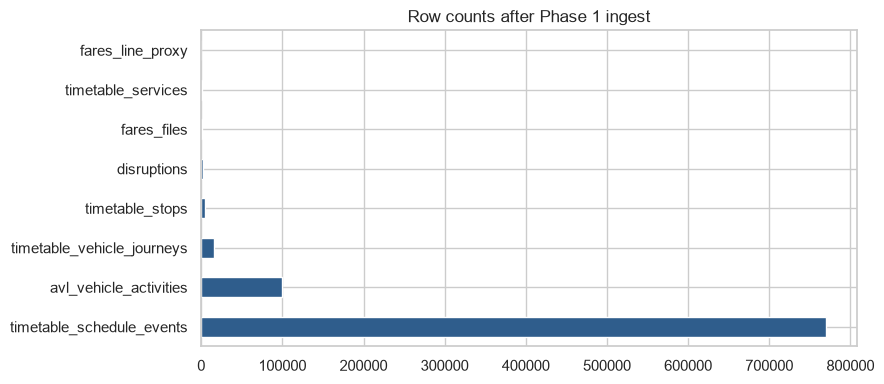

PosixPath('/Users/suhritsatyal/Desktop/softwarica_bachelors/big-data-coursework/visuals/data_exploration/01_row_counts.png')

In [13]:
DATA_EXPLORATION_DIR.mkdir(parents=True, exist_ok=True)
names = ["timetable_stops", "timetable_services", "timetable_vehicle_journeys",
         "timetable_schedule_events", "avl_vehicle_activities", "fares_files",
         "fares_line_proxy", "disruptions"]
counts = {n: len(pd.read_parquet(PROCESSED_DIR / f"{n}.parquet")) for n in names}
counts_s = pd.Series(counts).sort_values(ascending=False)
print(counts_s.to_string())
fig, ax = plt.subplots(figsize=(9, 4))
counts_s.plot(kind="barh", ax=ax, color="#2f5d8c")
ax.set_title("Row counts after Phase 1 ingest")
show_and_save(fig, DATA_EXPLORATION_DIR / "01_row_counts.png")


,n_journeys
line_name,
86A,1140
82,486
79,466
15,382
7,352
G10B,327
14,322
75,314
31,293


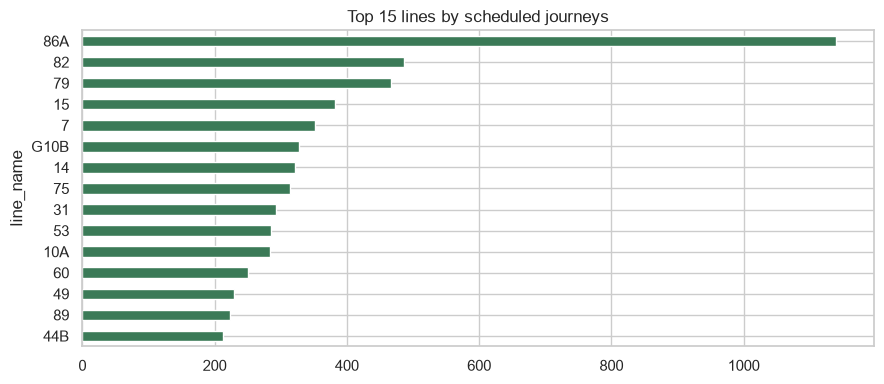

PosixPath('/Users/suhritsatyal/Desktop/softwarica_bachelors/big-data-coursework/visuals/data_exploration/02_top_lines.png')

In [14]:
vj = pd.read_parquet(PROCESSED_DIR / "timetable_vehicle_journeys.parquet")
top_lines = vj["line_name"].value_counts().head(15)
display(top_lines.to_frame("n_journeys"))
fig, ax = plt.subplots(figsize=(9, 4))
top_lines.sort_values().plot(kind="barh", ax=ax, color="#3b7a57")
ax.set_title("Top 15 lines by scheduled journeys")
show_and_save(fig, DATA_EXPLORATION_DIR / "02_top_lines.png")


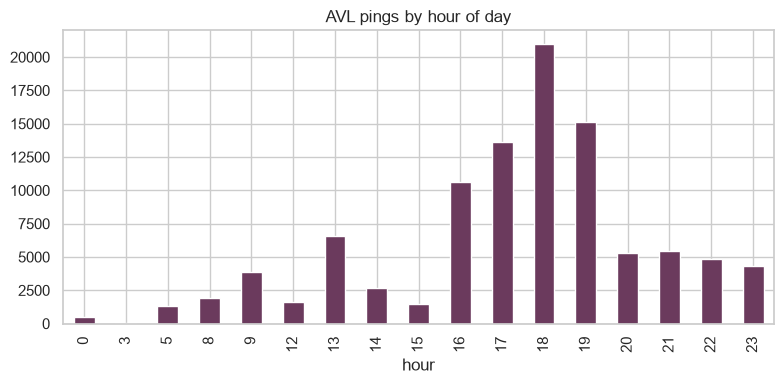

PosixPath('/Users/suhritsatyal/Desktop/softwarica_bachelors/big-data-coursework/visuals/data_exploration/03_avl_by_hour.png')

In [15]:
avl_pdf = pd.read_parquet(PROCESSED_DIR / "avl_vehicle_activities.parquet")
avl_pdf["hour"] = pd.to_datetime(avl_pdf["recorded_at_time"]).dt.hour
by_hour = avl_pdf["hour"].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(8, 4))
by_hour.plot(kind="bar", ax=ax, color="#6b3a5d")
ax.set_title("AVL pings by hour of day")
show_and_save(fig, DATA_EXPLORATION_DIR / "03_avl_by_hour.png")


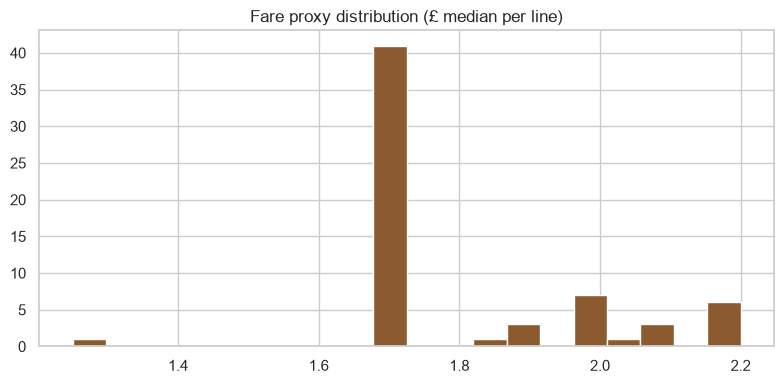

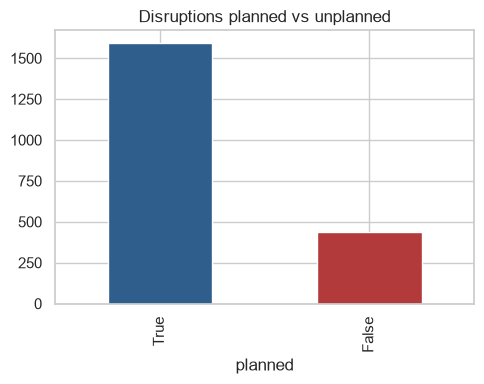

In [16]:
proxy = pd.read_parquet(PROCESSED_DIR / "fares_line_proxy.parquet")
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(proxy["fare_proxy_median"].dropna(), bins=20, color="#8c5a2f")
ax.set_title("Fare proxy distribution (£ median per line)")
show_and_save(fig, DATA_EXPLORATION_DIR / "04_fare_proxy.png")

dis = pd.read_parquet(PROCESSED_DIR / "disruptions.parquet")
if "planned" in dis.columns:
    fig, ax = plt.subplots(figsize=(5, 4))
    dis["planned"].value_counts().plot(kind="bar", ax=ax, color=["#2f5d8c", "#b33a3a"])
    ax.set_title("Disruptions planned vs unplanned")
    show_and_save(fig, DATA_EXPLORATION_DIR / "05_disruptions.png")


# Phase 1 complete
***
